# MILK tutorial: PBMC 3k dataset

This notebook provides a basic walkthrough of how MILK can be applied to scRNA-seq datasets. Specifically, using the processed 3k PBMCs from 10X Genomics obtained from the ["Preprocessing and clustering 3k PBMCs (legacy workflow)"](https://scanpy.readthedocs.io/en/stable/generated/scanpy.datasets.pbmc3k_processed.html), which is provided by Scanpy.

# Importing libraries

In [1]:
import os
import pathlib
import pandas as pd
import scanpy as sc

## Loading the dataset

In [3]:
adata = sc.datasets.pbmc3k_processed()
adata

  0%|          | 0.00/23.5M [00:00<?, ?B/s]

AnnData object with n_obs × n_vars = 2638 × 1838
    obs: 'n_genes', 'percent_mito', 'n_counts', 'louvain'
    var: 'n_cells'
    uns: 'draw_graph', 'louvain', 'louvain_colors', 'neighbors', 'pca', 'rank_genes_groups'
    obsm: 'X_pca', 'X_tsne', 'X_umap', 'X_draw_graph_fr'
    varm: 'PCs'
    obsp: 'distances', 'connectivities'

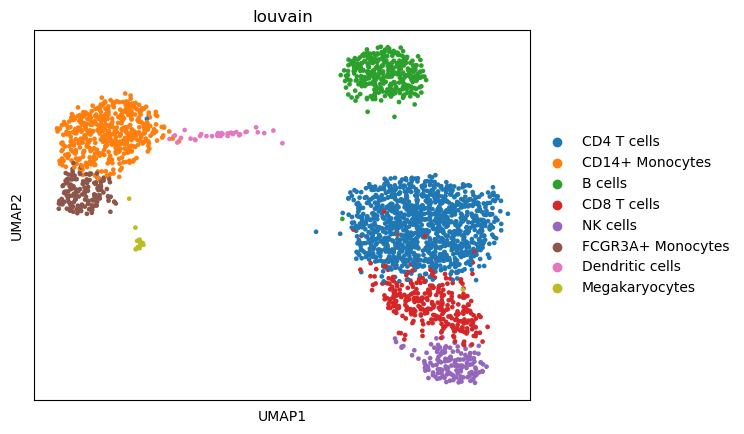

In [4]:
sc.pl.umap(adata,color="louvain")

In [49]:
adata

AnnData object with n_obs × n_vars = 2638 × 1838
    obs: 'n_genes', 'percent_mito', 'n_counts', 'louvain'
    var: 'n_cells'
    uns: 'draw_graph', 'louvain', 'louvain_colors', 'neighbors', 'pca', 'rank_genes_groups'
    obsm: 'X_pca', 'X_tsne', 'X_umap', 'X_draw_graph_fr'
    varm: 'PCs'
    obsp: 'distances', 'connectivities'

In [5]:
input_df = pd.DataFrame(adata.obsm["X_pca"],index=adata.obs_names)
input_df.to_csv("input.csv",header=False)
display(input_df.head())
print(input_df.shape)

,0,1,2,3,4,5,6,7,8,9,...,40,41,42,43,44,45,46,47,48,49
index,,,,,,,,,,,,,,,,,,,,,
AAACATACAACCAC-1,5.556233,0.257714,-0.186810,2.800131,-0.033783,-0.189702,0.310228,-1.323691,2.691945,0.125928,...,-0.266174,1.024464,-0.709844,-0.052780,-0.686898,-1.419867,-2.865078,0.027601,2.671032,-0.297620
AAACATTGAGCTAC-1,7.209530,7.481985,0.162706,-8.018575,3.012900,0.322293,2.270888,-0.605055,-0.905611,1.225260,...,0.158161,0.819037,0.578912,-1.169742,0.955408,0.068133,-0.883082,2.930932,0.354197,-1.081801
AAACATTGATCAGC-1,2.694438,-1.583658,-0.663126,2.205649,-1.686360,-1.965395,-1.894999,-1.522103,1.914985,-0.481202,...,-1.054254,0.805932,1.543282,1.504834,-0.831818,-0.236549,1.883515,1.084782,0.381470,0.064662
AAACCGTGCTTCCG-1,-10.143295,-1.368530,1.209812,-0.700096,-2.872336,0.230617,1.278005,0.487900,-0.447965,-0.328465,...,1.297246,0.611073,-0.007878,-0.648735,0.543566,3.156763,1.691134,-0.301377,-0.225427,0.962879
AAACCGTGTATGCG-1,-1.112816,-8.152788,1.332405,-4.252473,2.036407,5.597797,-0.110658,-0.102257,0.014520,0.581409,...,1.191032,1.042533,1.734694,-0.142114,0.586381,0.636326,-1.451625,1.809683,-0.087072,-0.737833


(2638, 50)


## MILK execution

### Exporting MILK directory to PATH

Assuming directory structure remains unchanged, and the current `tutorial` directory is a subdirectory of the parent `milk` directory.

In [6]:
milk_dir = pathlib.Path().resolve().parent
os.environ["PATH"] += f":{milk_dir}"

In [7]:
%%bash

milk -h

  Activating project at `~/work/RepresentativeSubsampling/milk`


usage: milk -i INPUT-PATH [-b BATCH-SIZE] [-n SAMPLE-SIZE]
            [-c CACHE-SIZE-LIMIT] [-p PARTITION-SIZE]
            [-M MERGE-THRESHOLD] [-P COMPILE-PREVIOUS-THRESHOLD]
            [-m METRIC] [-l LABEL] [-t PERCENTILE] [-T THREADS]
            [-r SEED] [--job-scheduler JOB-SCHEDULER]
            [--job-account JOB-ACCOUNT] [--job-name JOB-NAME]
            [--job-memory JOB-MEMORY] [--job-time JOB-TIME]
            [--environment-path ENVIRONMENT-PATH] [--verbose]
            [--force-overwrite] [--skip-reconstruction]
            [-o OUTPUT-DIR] [--group-stratification-mode]
            [--stratification-input-dir STRATIFICATION-INPUT-DIR]
            [--stratification-threshold STRATIFICATION-THRESHOLD]
            [--stratification-percentile STRATIFICATION-PERCENTILE]
            [--stratification-metric STRATIFICATION-METRIC]
            [--stratification-cache-path STRATIFICATION-CACHE-PATH]
            [--stratification-previous-groups-path STRATIFICATION-PREVIOUS-GRO

In [116]:
%%bash

milk -i input.csv -t 0.1 -m "euclidean" --force-overwrite

  Activating project at `~/work/RepresentativeSubsampling/milk`


[ Info: MILK
[ Info: Using 1 worker(s) for distributed processing
[ Info: Parsed Arguments:
[ Info:   label: nothing
[ Info:   percentile: 0.1
[ Info:   compile-previous-threshold: 1000000
[ Info:   batch-size: 50
[ Info:   output-dir: ./milk.out
[ Info:   merge-threshold: 100000
[ Info:   sample-size: 1
[ Info:   threads: 1
[ Info:   cache-size-limit: 50000
[ Info:   job-time: 24:00:00
[ Info:   group-stratification-mode: false
[ Info:   job-name: milk
[ Info:   partition-size: 10000
[ Info:   skip-reconstruction: false
[ Info:   metric: euclidean
[ Info:   verbose: false
[ Info:   job-scheduler: nothing
[ Info:   environment-path: nothing
[ Info:   force-overwrite: true
[ Info:   job-account: nothing
[ Info:   job-memory: 4
[ Info:   seed: 21
[ Info:   input-path: input.csv
[ Info: ==========
┌ Warning: Output directory already exists! Overwriting.
└ @ Milk /rshare1/ZETTAI_path_WA_slash_home_KARA/home/brett/work/RepresentativeSubsampling/milk/src/main.jl:29
[ Info: Iteration: 0 (2638

# Analysis of single-cell MILK embedding

In [52]:
import numpy as np
import graph_tool.all as gt
import seaborn as sns
import matplotlib.cm as cm
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import matplotlib.colors as mcolors
from collections import defaultdict,deque
from Bio import Phylo
from Bio.Phylo.BaseTree import Tree,Clade

from glob import glob
from tqdm import tqdm

In [11]:
gt.openmp_set_num_threads(1)

In [12]:
def instantiate_node(node_id,info_dict):
    node = Clade(name=node_id)
    node_dict = info_dict[node_id]
    node.representative_id = node_dict["representative_id"]
    node.group_size = node_dict["group_size"]
    node.iteration = node_dict["iteration"]
    node.threshold = node_dict["threshold"]
    node.spread = node_dict["spread"]
    node.specificity = node_dict["specificity"]
    node.resolution = node_dict["resolution"]
    return node

def construct_tree_object(vertices_df,edges_df):
    """
    For each (parent) node, provide list of (children) subnodes (top is root; bottom refers to leaves)
    """
    descendents_dict = edges_df.groupby("source")["target"].apply(list).to_dict()
    max_iteration_df = vertices_df[vertices_df["iteration"] == vertices_df["iteration"].max()]
    assert max_iteration_df.shape[0] == 1 # there must only be one group at end if MILK runs successfully

    root_id = max_iteration_df["node_id"].values[0]
    node_info_dict = vertices_df.set_index("node_id").to_dict(orient="index")

    root_node = instantiate_node(root_id,node_info_dict)
    queue = deque([root_node])
    while queue:
        clade = queue.popleft()
        subclades = []
        for sample_id in descendents_dict.get(clade.name,[]):
            subclade = instantiate_node(sample_id,node_info_dict)
            subclades.append(subclade)
            queue.append(subclade)
        clade.clades = subclades

    return Tree(root_node)

In [117]:
vertices_path = os.path.join(".","milk.out","output","vertices.csv.gz")
edges_path = os.path.join(".","milk.out","output","edges.csv.gz")

vertices_df = pd.read_csv(vertices_path)
display(vertices_df.head())
print(vertices_df.shape)

edges_df = pd.read_csv(edges_path)
display(edges_df.head())
print(edges_df.shape)

,node_id,representative_id,group_size,iteration,threshold,spread,specificity,resolution
0,CAATCGGAGAAACA-1,CAATCGGAGAAACA-1,1,0,0.000000,NaN,NaN,0
1,TTCTACGAACGTAC-1,TTCTACGAACGTAC-1,1,0,0.000000,NaN,NaN,0
2,I1,CAATCGGAGAAACA-1,2,1,9.160102,9.155311,1.0,1
3,CCTCGAACACTTTC-1,CCTCGAACACTTTC-1,1,0,0.000000,NaN,NaN,0
4,I2,CCTCGAACACTTTC-1,1,1,9.160102,NaN,NaN,0


(18336, 8)


,source,target
0,I1,CAATCGGAGAAACA-1
1,I1,TTCTACGAACGTAC-1
2,I2,CCTCGAACACTTTC-1
3,I3,GAACCTGATGAACC-1
4,I4,GAGGTTTGTAAGCC-1


(18335, 2)


In [118]:
tree = construct_tree_object(vertices_df,edges_df)
tree.count_terminals()

2638

In [119]:
labels = sorted(adata.obs["louvain"].unique())
labels

['B cells',
 'CD14+ Monocytes',
 'CD4 T cells',
 'CD8 T cells',
 'Dendritic cells',
 'FCGR3A+ Monocytes',
 'Megakaryocytes',
 'NK cells']

In [120]:
labels_dict = {}
for sample_id,label in zip(adata.obs_names,adata.obs["louvain"]):
    labels_dict[sample_id] = label

In [121]:
color_dict = {}
for label,col in zip(adata.obs['louvain'].cat.categories,adata.uns["louvain_colors"]):
    color_dict[label] = tuple(list(mcolors.to_rgb(col))+[0.75])

In [127]:
neutral_col = (0.75,0.75,0.75,0.25)
neutral_threshold = 0.8

g = gt.Graph(directed=False)

vertex_labels = g.new_vertex_property("vector<float>")
vertex_sizes = g.new_vertex_property("float")
edge_widths = g.new_edge_property("int")

vertex = g.add_vertex()

vertex_labels[vertex] = neutral_col # color_dict[labels_dict[tree.clade.representative_id]]
vertex_sizes[vertex] = np.log1p(tree.count_terminals())*2

stack = [(vertex,tree.clade)]
while stack:
    vertex,clade = stack.pop()
    for subclade in clade:
        subvertex = g.add_vertex()
        edge = g.add_edge(vertex,subvertex)
        representative_label = labels_dict[subclade.representative_id]
        representative_col = color_dict[representative_label]
        leaf_labels = []
        for leaf in subclade.get_terminals():
            leaf_labels.append(labels_dict[leaf.representative_id])
        prop_matching = np.mean([int(representative_label == label) for label in leaf_labels])
        if prop_matching >= neutral_threshold:
            vertex_labels[subvertex] = color_dict[labels_dict[subclade.representative_id]]
        else:
            vertex_labels[subvertex] = neutral_col
        vertex_sizes[subvertex] = np.log1p(subclade.count_terminals())*2
        edge_widths[edge] = np.log1p(subclade.count_terminals())

        stack.append((subvertex,subclade))

g.vertex_properties["cell_type"] = vertex_labels
g.vertex_properties["group_size"] = vertex_sizes
g.edge_properties["pen_width"]    = edge_widths

In [128]:
pos = gt.sfdp_layout(g)

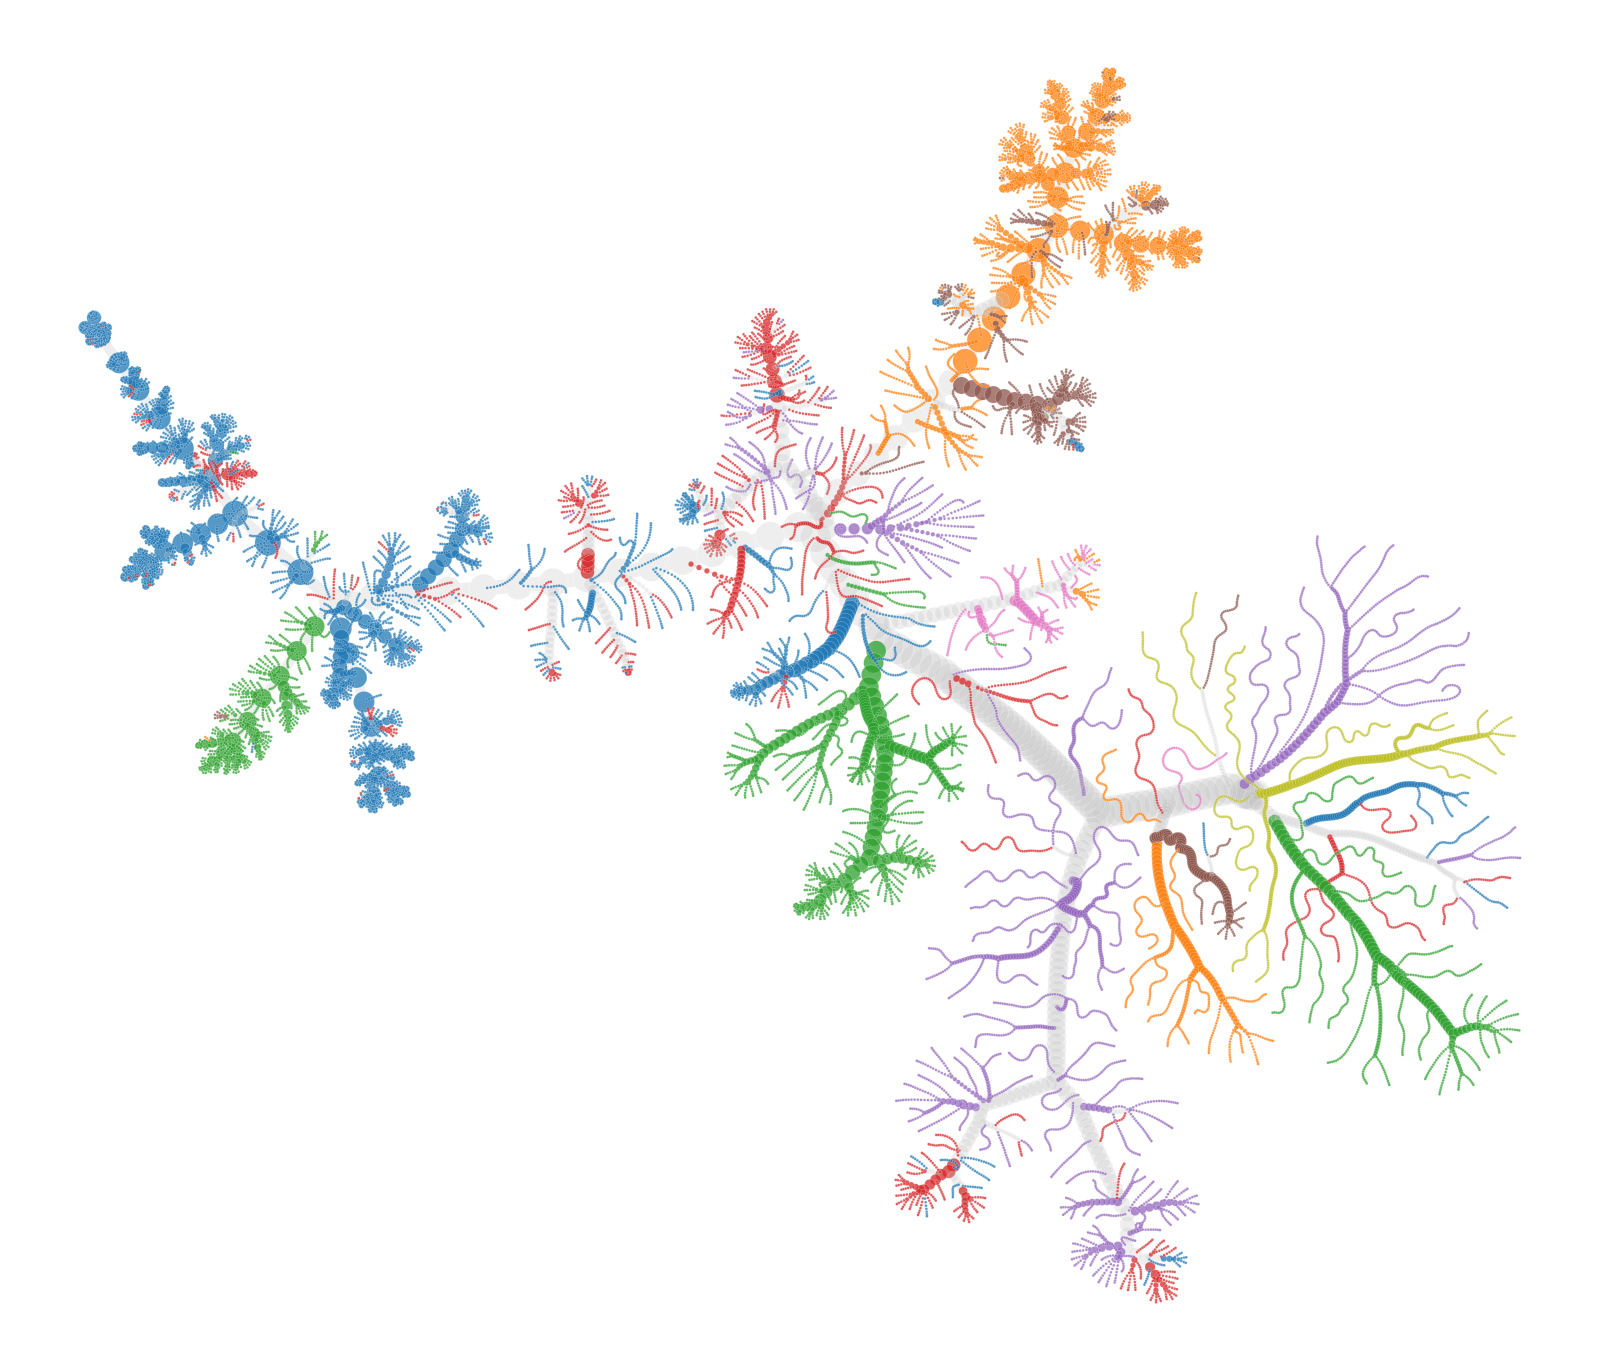

<VertexPropertyMap object with value type 'vector<double>', for Graph 0x1511d62cafd0, at 0x1511d6910280>

In [129]:
gt.graph_draw(
    g,
    pos=pos,
    vertex_fill_color=vertex_labels,
    vertex_color=[1,1,1,0.5],
    edge_color=[0.75,0.75,0.75,0.25],
    edge_pen_width=edge_widths,
    vertex_size=vertex_sizes,
    output_size=(800,1000),
    bg_color=None
)

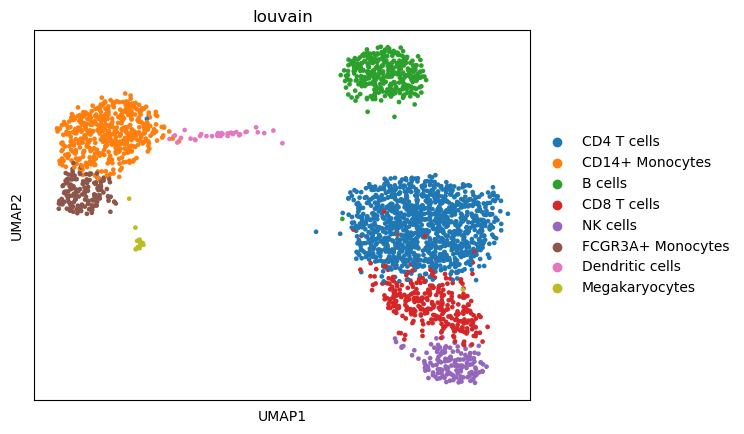

In [115]:
sc.pl.umap(adata,color="louvain")